В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [497]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as tts
from sklearn import preprocessing as prep
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [498]:
df = pd.read_csv("cars.csv")
df.head(5)

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [499]:
# General info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [500]:
# Check exact types of 'object' columns
df_objects = df.select_dtypes(include="object")

for obj in df_objects:
    print(f"{obj} - {type(obj)}")

Brand - <class 'str'>
Model - <class 'str'>
Fuel_Type - <class 'str'>
Transmission - <class 'str'>
Owner_Type - <class 'str'>


In [501]:
# Numerical types number
df_numbers = df.select_dtypes(include="number")
df_numbers.shape

(100, 8)

In [502]:
# Other (categorial) types number
df_other = df.select_dtypes(exclude="number")
df_other.shape

(100, 5)

In [503]:
# Method to print values info for categorial columns
def print_column_info(column_name):
    print("---", column_name, "---")
    print("Number of unique values:", df[column_name].nunique())
    print("Unique values:", df[column_name].unique())

In [504]:
# Print info for all categorial columns
for column in df_other.columns:
    print_column_info(column)

--- Brand ---
Number of unique values: 11
Unique values: ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']
--- Model ---
Number of unique values: 58
Unique values: ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']
--- Fuel_Type ---
Number of unique values: 2
Unique values: ['Petrol' 'Diesel']
--- Transmission ---
Number of unique values: 2
Unique values: ['Manual' 'Automatic']
--- Owner_Type ---
Number of unique values: 3
Unique values: ['First' 'Second' 'Third']


**Висновок**

Даний датасет має:
- 8 колонок числового типу
- 5 категоріальних колонок, з яких:
  - 2 бінарні
  - 2 мультикатегоріальні
  - 1 колонка, в якій можна встановити відношення порядку (`Owner_Type`)

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [505]:
# Split dataset for training and testing
df_target = df.Price
df_params = df[[col for col in df.columns if col != "Price"]]

X_train, X_test, y_train, y_test = tts(df_params, df_target, test_size=0.2, random_state=12)

**Check that dataset was split correctly**

In [506]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(80, 12) (20, 12) (80,) (20,)


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

#### 1. Binary columns transformation

In [507]:
X_train["Fuel_Type"].value_counts()

Fuel_Type
Petrol    41
Diesel    39
Name: count, dtype: int64

In [508]:
# Adding "Fuel_Type_Code" numerical column
fuel_type_codes = {"Petrol": 1, "Diesel": 0}
X_train["Fuel_Type_Code"] = X_train["Fuel_Type"].map(fuel_type_codes)
X_test["Fuel_Type_Code"] = X_test["Fuel_Type"].map(fuel_type_codes)
X_test.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1


In [509]:
X_train["Transmission"].value_counts()

Transmission
Automatic    49
Manual       31
Name: count, dtype: int64

In [510]:
# Adding "Transmission_Code" numerical column
transmission_codes = {"Automatic": 1, "Manual": 0}
X_train["Transmission_Code"] = X_train["Transmission"].map(transmission_codes)
X_test["Transmission_Code"] = X_test["Transmission"].map(transmission_codes)
X_test.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0


#### 2. `Brand` column transformation

In [511]:
# Fitting categories for "Brand" column
oh_encoder = prep.OneHotEncoder()
oh_encoder.fit(X_train[["Brand"]])
oh_encoder.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [512]:
# Adding transformed columns to datasets
X_train[oh_encoder.categories_[0]] = oh_encoder.transform(X_train[["Brand"]]).toarray()
X_test[oh_encoder.categories_[0]] = oh_encoder.transform(X_test[["Brand"]]).toarray()
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(None, None)

#### 3. `Owner_Type` column transformation

In [513]:
# визначаємо порядок категорій
ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']])
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

In [514]:
print(X_train["Owner_Type"].unique(), X_train["Owner_Type_Codes"].unique())

['Second' 'First' 'Third'] [1. 0. 2.]


**Спостереження**
- В цьому перетворенні категоріальні значення були трансформовані у числа згідно з вказаним порядком: First -> 0, Second -> 1, Third -> 2. 

#### 4. `Model` column transformation

In [515]:
# Check value counts for Model column
X_train["Model"].value_counts().sort_values(ascending=False)

Model
Mustang          3
Altroz           3
C-Class          3
Camry            2
XUV300           2
S-Cross          2
Ranger           2
A3               2
Tiago            2
Fortuner         2
GLE              2
Q7               2
A6               2
Tigor            2
Vitara           2
X3               2
Verna            2
A5               2
EcoSport         2
7 Series         2
Ameo             2
WR-V             2
T-Roc            2
X5               2
3 Series         2
BR-V             2
E-Class          2
Passat           2
Sonata           1
Innova Crysta    1
Yaris            1
Santro           1
Venue            1
Endeavour        1
Civic            1
Elantra          1
GLC              1
Vento            1
Safari           1
5 Series         1
Swift            1
GLA              1
Nexon            1
Harrier          1
Corolla          1
Thar             1
Aspire           1
Innova           1
Scorpio          1
Name: count, dtype: int64

**Спостереження**

У нас багато значень Model, але мало екземплярів кожного з них (максимум три).
Тому спробуємо такі підходи:
- Просто видалити цей стовпець
- Розбити трейн і тест датасети на 4 категорії по кількості значень у трейні: окремо кожна модель, що має 3 екземпляри і решта - в одну категорію Other.
    - Закодувати їх за допомогою `TargetEncoder`
    - Закодувати їх за допомогою `OneHotEncoder`

Результати порівняємо на стадії передбачення таргета на Тест датасеті.

##### 4.1. Using `TargetEncoder`

In [516]:
# Add additional "Model_Categorized" column based on "Model"
# where vslues with count less than 3 are replaced with "Other" value
models_vc = X_train["Model"].value_counts()
models_to_keep = models_vc[models_vc >= 3].index

X_train["Model_Categorized"] = X_train["Model"].where(
                                                    X_train["Model"].isin(models_to_keep),
                                                    "Other")
X_test["Model_Categorized"] = X_test["Model"].where(
                                                    X_test["Model"].isin(models_to_keep),
                                                    "Other")
display(X_train.head(10)), display(X_test.head(10))

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Categorized
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Other
57,58,Mercedes,C-Class,2019,22000,Diesel,Automatic,First,16,1950,191,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,C-Class
46,47,Audi,Q7,2017,30000,Diesel,Automatic,First,14,2967,245,7,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other
23,24,Tata,Altroz,2020,18000,Petrol,Manual,First,20,1199,85,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Altroz
36,37,Audi,A3,2017,38000,Petrol,Automatic,Second,16,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other
91,92,Mahindra,XUV300,2019,26000,Diesel,Manual,Second,20,1497,115,5,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,Other


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Categorized
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Other
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other
31,32,Hyundai,Elantra,2017,32000,Diesel,Automatic,Second,22,1582,126,5,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other
89,90,Hyundai,Venue,2018,32000,Petrol,Manual,Third,17,1197,81,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other
15,16,Honda,City,2017,42000,Diesel,Manual,Second,25,1498,98,5,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other
21,22,Ford,Figo,2020,15000,Petrol,Manual,Third,18,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other
60,61,Hyundai,Verna,2019,24000,Petrol,Automatic,Second,17,1497,113,5,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other


(None, None)

In [517]:
# Use TargetEncoder to get values for "Model_Categorized"
tar_enc = prep.TargetEncoder(shuffle=True, random_state=42, target_type="continuous")
X_trans = tar_enc.fit_transform(X_train[["Model_Categorized"]], y_train)
X_trans[:5]

array([[1616359.73672116],
       [1673098.26023643],
       [1673098.26023643],
       [1701604.39977276],
       [1616359.73672116]])

In [518]:
# Create new numeric column with that values
X_train["Model_Encoded"] = X_trans[:, 0]
X_test["Model_Encoded"] = tar_enc.transform(X_test[["Model_Categorized"]])
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Categorized,Model_Encoded
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,1.616360e+06
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,1.673098e+06
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,1.673098e+06
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,1.701604e+06
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Other,1.616360e+06


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Categorized,Model_Encoded
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other,1.642777e+06
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other,1.642777e+06
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,1.642777e+06
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Other,1.642777e+06
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other,1.642777e+06


(None, None)

##### 4.2. Using `OneHotEncoder`

In [519]:
oh_enc = prep.OneHotEncoder()
oh_enc.fit(X_train[["Model_Categorized"]])
oh_enc.categories_

[array(['Altroz', 'C-Class', 'Mustang', 'Other'], dtype=object)]

In [520]:
X_train[oh_enc.categories_[0]] = oh_enc.transform(X_train[["Model_Categorized"]]).toarray()
X_test[oh_enc.categories_[0]] = oh_enc.transform(X_test[["Model_Categorized"]]).toarray()
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Categorized,Model_Encoded,Altroz,C-Class,Mustang,Other
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,1.616360e+06,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,1.673098e+06,0.0,0.0,0.0,1.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,1.673098e+06,0.0,0.0,0.0,1.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,1.701604e+06,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Other,1.616360e+06,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Categorized,Model_Encoded,Altroz,C-Class,Mustang,Other
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other,1.642777e+06,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other,1.642777e+06,0.0,0.0,0.0,1.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,1.642777e+06,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Other,1.642777e+06,0.0,0.0,0.0,1.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other,1.642777e+06,0.0,0.0,0.0,1.0


(None, None)

**Очікуваний результат після трансформацій:**

In [521]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Categorized,Model_Encoded,Altroz,C-Class,Mustang,Other
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,1.616360e+06,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,1.673098e+06,0.0,0.0,0.0,1.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,1.673098e+06,0.0,0.0,0.0,1.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,1.701604e+06,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Other,1.616360e+06,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Categorized,Model_Encoded,Altroz,C-Class,Mustang,Other
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other,1.642777e+06,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other,1.642777e+06,0.0,0.0,0.0,1.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,1.642777e+06,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Other,1.642777e+06,0.0,0.0,0.0,1.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other,1.642777e+06,0.0,0.0,0.0,1.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [522]:
# Remove non-number columns from train data
X_train = X_train.select_dtypes(include="number")
X_train.shape

(80, 26)

In [523]:
# Build dataframe for train set to analyze correlation
df_train = pd.concat([X_train, y_train], axis=1)
df_train.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Encoded,Altroz,C-Class,Mustang,Other,Price
83,84,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.616360e+06,0.0,0.0,0.0,1.0,1600000
55,56,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.673098e+06,0.0,0.0,0.0,1.0,2600000
26,27,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.673098e+06,0.0,0.0,0.0,1.0,3200000
54,55,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.701604e+06,0.0,0.0,0.0,1.0,650000
19,20,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.616360e+06,0.0,0.0,0.0,1.0,2500000


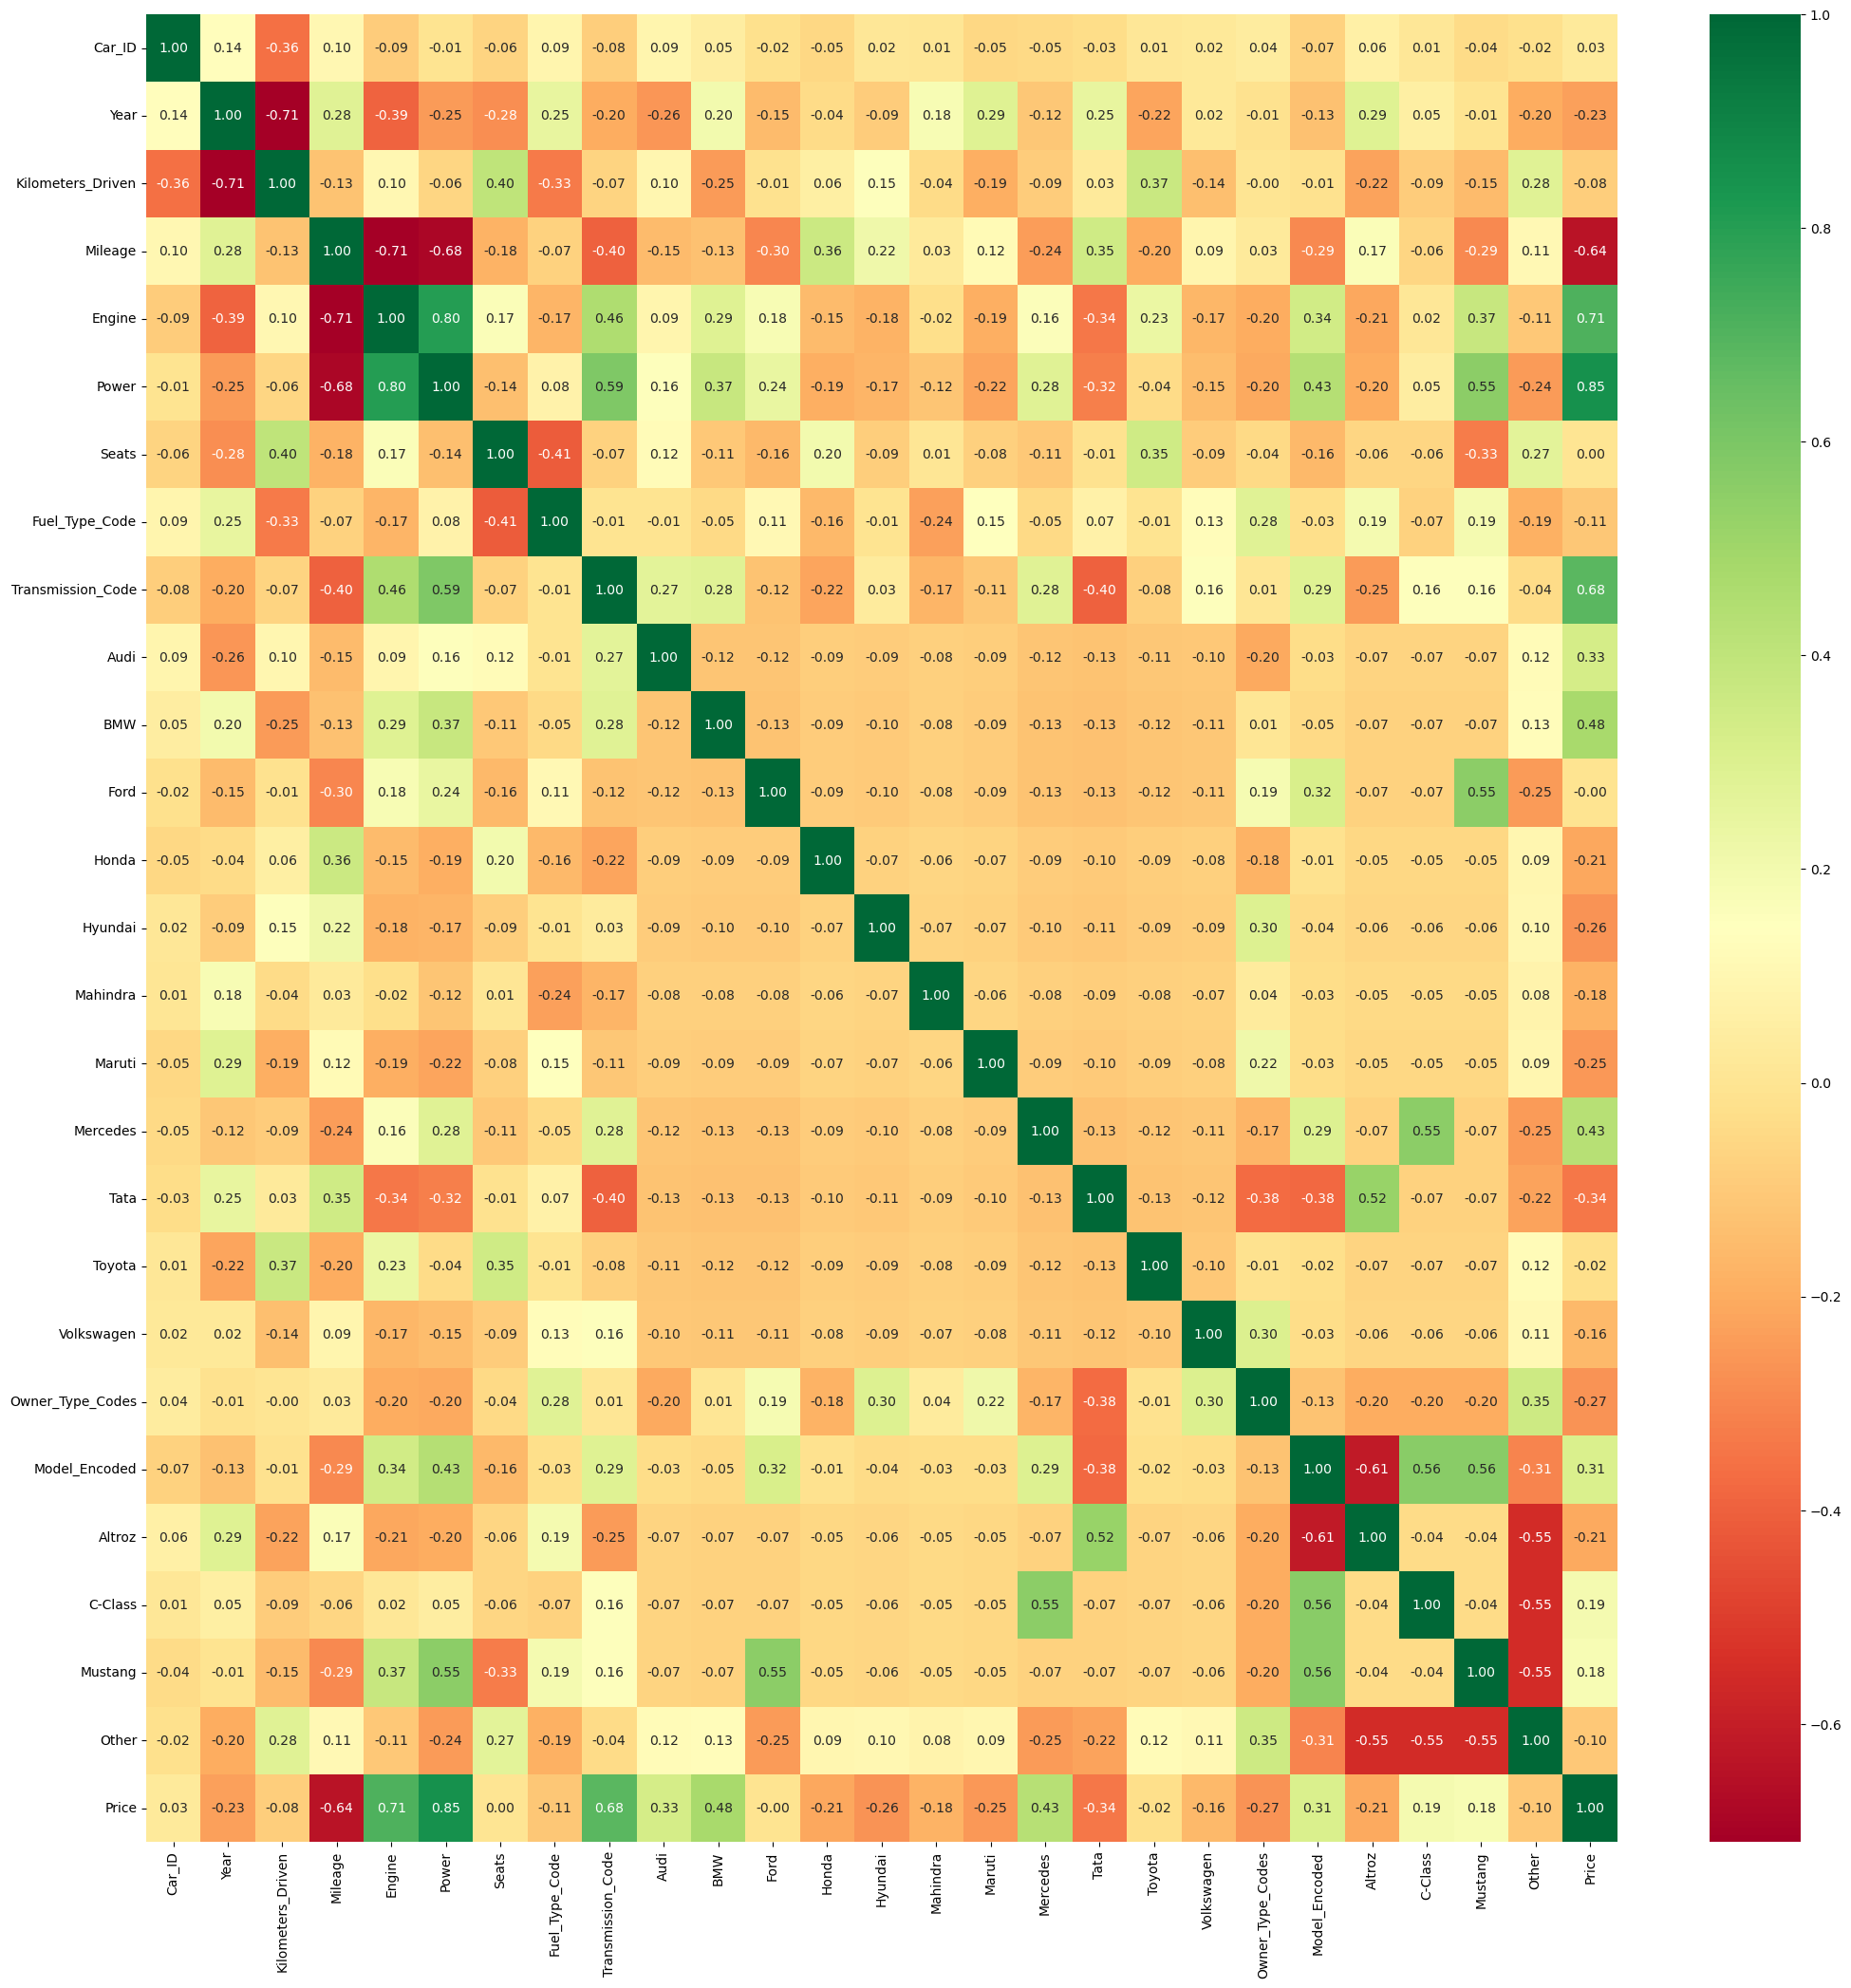

In [524]:
# Build correlation matrix
df_train_corr = df_train.corr()

plt.figure(figsize=(25, 25))
sns.heatmap(data=df_train_corr, annot=True, cmap="RdYlGn", cbar=True, fmt='.2f')
plt.show()

**Висновок**

Параметри, які мають кореляцію з таргетом `Price` більше 0.5:
- Позитивну: `Power` (0.85), `Engine` (0.71), `Transmission_Code` (0.68)
- Негативну: `Mileage` (-0.64)

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [525]:
# Remove non-number columns from test data
X_test = X_test.select_dtypes(include="number")

# Remove "Car_ID" from train and test sets
X_train = X_train.drop(["Car_ID"], axis=1)
X_test = X_test.drop(["Car_ID"], axis=1)

print(X_train.shape, X_test.shape)

(80, 25) (20, 25)


### Порівняння 3 варіантів моделей стосовно параметра `Model`

#### 1. Для датасету без параметра `Model`

In [526]:
# Remove all columns generated from "Model" from train and test sets
X_train_1 = X_train.drop(["Model_Encoded", "Other"] + models_to_keep.to_list(), axis=1)
X_test_1 = X_test.drop(["Model_Encoded", "Other"] + models_to_keep.to_list(), axis=1)
display(X_train_1.head()), display(X_test_1.head())

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,2016,38000,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,2019,26000,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,2020,18000,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,2019,26000,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

In [527]:
# Training model
model_1 = LinearRegression()
model_1.fit(X_train_1, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [528]:
# Predict target
pred_train_1 = model_1.predict(X_train_1)
pred_test_1 = model_1.predict(X_test_1)

# Calculate Root Mean Square Error
rmse_train_1 = root_mean_squared_error(y_train, pred_train_1)
rmse_test_1 = root_mean_squared_error(y_test, pred_test_1)

print(f"Root Mean Square Error for TRAIN data: {rmse_train_1}")
print(f"Root Mean Square Error for TEST data: {rmse_test_1}")

Root Mean Square Error for TRAIN data: 210342.80162046466
Root Mean Square Error for TEST data: 259601.26542723688


#### 2. Для датасету з використанням `TargetEncoder` на `Model`

In [529]:
# Remove all columns generated with OneHotEncoder for "Model" from train and test sets
X_train_2 = X_train.drop(["Other"] + models_to_keep.to_list(), axis=1)
X_test_2 = X_test.drop(["Other"] + models_to_keep.to_list(), axis=1)
display(X_train_2.head()), display(X_test_2.head())

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Encoded
83,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.616360e+06
55,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.673098e+06
26,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.673098e+06
54,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.701604e+06
19,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.616360e+06


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Encoded
17,2016,38000,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.642777e+06
41,2019,26000,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.642777e+06
92,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.642777e+06
14,2020,18000,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.642777e+06
68,2019,26000,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.642777e+06


(None, None)

In [530]:
# Training model
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [531]:
# Predict target
pred_train_2 = model_2.predict(X_train_2)
pred_test_2 = model_2.predict(X_test_2)

# Calculate Root Mean Square Error
rmse_train_2 = root_mean_squared_error(y_train, pred_train_2)
rmse_test_2 = root_mean_squared_error(y_test, pred_test_2)

print(f"Root Mean Square Error for TRAIN data: {rmse_train_2}")
print(f"Root Mean Square Error for TEST data: {rmse_test_2}")

Root Mean Square Error for TRAIN data: 209268.15974362084
Root Mean Square Error for TEST data: 258445.84756627388


#### 3. Для датасету з використанням `OneHotEncoder` на `Model`

In [532]:
# Remove column generated with TargetEncoder for "Model" from train and test sets
X_train_3 = X_train.drop(["Model_Encoded"], axis=1)
X_test_3 = X_test.drop(["Model_Encoded"], axis=1)
display(X_train_3.head()), display(X_test_3.head())

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Altroz,C-Class,Mustang,Other
83,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
55,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
26,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
54,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
19,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Altroz,C-Class,Mustang,Other
17,2016,38000,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
41,2019,26000,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0
92,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
14,2020,18000,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
68,2019,26000,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0


(None, None)

In [533]:
# Training model
model_3 = LinearRegression()
model_3.fit(X_train_3, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [534]:
# Predict target
pred_train_3 = model_3.predict(X_train_3)
pred_test_3 = model_3.predict(X_test_3)

# Calculate Root Mean Square Error
rmse_train_3 = root_mean_squared_error(y_train, pred_train_3)
rmse_test_3 = root_mean_squared_error(y_test, pred_test_3)

print(f"Root Mean Square Error for TRAIN data: {rmse_train_3}")
print(f"Root Mean Square Error for TEST data: {rmse_test_3}")

Root Mean Square Error for TRAIN data: 198129.4876177331
Root Mean Square Error for TEST data: 260670.9730400869


#### Вибір моделі з 3 варіантів

In [535]:
# Compare RMSE for 3 model options
print(f"--- RMSE for model_1 ---\nTrain: {rmse_train_1} | Test: {rmse_test_1}\n")
print(f"--- RMSE for model_2 ---\nTrain: {rmse_train_2} | Test: {rmse_test_2}\n")
print(f"--- RMSE for model_3 ---\nTrain: {rmse_train_3} | Test: {rmse_test_3}\n")

--- RMSE for model_1 ---
Train: 210342.80162046466 | Test: 259601.26542723688

--- RMSE for model_2 ---
Train: 209268.15974362084 | Test: 258445.84756627388

--- RMSE for model_3 ---
Train: 198129.4876177331 | Test: 260670.9730400869



**Висновок**

Загалом результати моделей на тестовому сеті дуже схожі. Причому результат без параметра `Model` виявився кращий, ніж отриманий з `OneHotEncoder` цього параметра. Найкращий результат показала Модель 2, тобто на датасеті з параметром `Model`, трансформованим за допомогою `TargetEncoder`.

Отже, обираємо `model_2`.

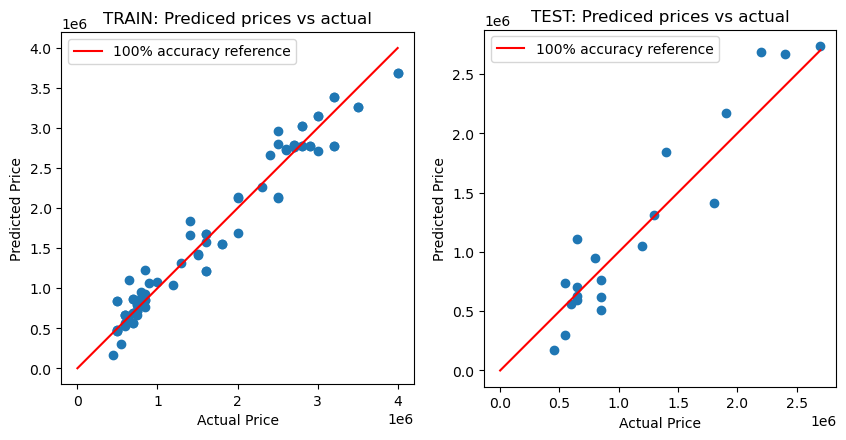

In [536]:
# Scatter plots to compare predicted prices to actual
# for both train and test data sets
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].scatter(x=y_train, y=pred_train_2)
axs[0].plot([0, y_train.max()], [0, y_train.max()], color="red", label="100% accuracy reference")
axs[0].set_box_aspect(1)
axs[0].set_aspect('equal', adjustable='box')
axs[0].set_title("TRAIN: Prediced prices vs actual")
axs[0].set_xlabel("Actual Price")
axs[0].set_ylabel("Predicted Price")
axs[0].legend()

axs[1].scatter(x=y_test, y=pred_test_2)
axs[1].plot([0, y_test.max()], [0, y_test.max()], color="red", label="100% accuracy reference")
axs[1].set_box_aspect(1)
axs[1].set_aspect('equal', adjustable='box')
axs[1].set_title("TEST: Prediced prices vs actual")
axs[1].set_xlabel("Actual Price")
axs[1].set_ylabel("Predicted Price")
axs[1].legend()

plt.show()

**Висновок**

- На тренувальних даних видно доволі хорошу точність моделі.
- На тестових даних теж є певна точність, але важко робити висновки, бо даних мало.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [537]:
# Creating new dataframes with scaled parameters
std_scaler = prep.StandardScaler()
X_train_std = pd.DataFrame(std_scaler.fit_transform(X_train_2), columns=X_train_2.columns)
X_test_std = pd.DataFrame(std_scaler.transform(X_test_2), columns=X_test_2.columns)

display(X_train_std.head()), display(X_test_std.head())

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Encoded
0,0.568813,-0.693871,0.274862,-0.628491,-0.231967,-0.303562,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303,-0.175742
1,-0.323442,-0.039533,-0.018324,0.087196,0.247012,-0.303562,-1.025320,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135,-0.012597
2,-0.323442,-0.039533,-0.604696,0.111560,0.910213,-0.303562,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135,-0.012597
3,-1.215697,0.396692,0.274862,-0.476217,-0.784634,-0.303562,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303,0.069369
4,-1.215697,-0.257646,-1.484254,0.122219,0.910213,-0.303562,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,2.808717,-0.377964,-0.333333,-0.309662,0.535303,-0.175742


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Encoded
0,-2.107952,1.051030,-0.604696,-0.785333,-0.231967,-0.303562,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,0.535303,-0.099782
1,0.568813,-0.257646,0.861234,-1.255859,-1.214487,-0.303562,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,3.511885,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,2.064742,-0.099782
2,-1.215697,0.396692,0.274862,-0.476217,-0.784634,-0.303562,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303,-0.099782
3,1.461068,-1.130096,0.568048,-0.683310,-0.784634,2.394771,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,3.872983,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135,-0.099782
4,0.568813,-0.257646,0.861234,-1.091404,-0.895168,-0.303562,0.975305,-1.257237,-0.333333,-0.356034,2.808717,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,2.064742,-0.099782


(None, None)

In [538]:
# Training model
model_std = LinearRegression()
model_std.fit(X_train_std, y_train)

# Show sorted coefficients
column_names = ["Bias"] + X_train_2.columns.to_list()
coefficients = np.concatenate(([model_std.intercept_], model_std.coef_))
coefs_table = pd.Series(coefficients.round(), index=column_names)
coefs_table.sort_values(key=abs, ascending=False)

Bias                 1680000.0
Power                 507509.0
Mercedes              215711.0
BMW                   204734.0
Audi                  203297.0
Fuel_Type_Code       -181586.0
Hyundai              -150171.0
Mahindra             -140655.0
Mileage              -122878.0
Transmission_Code     118179.0
Maruti               -110649.0
Ford                 -107142.0
Kilometers_Driven     -89688.0
Volkswagen            -89570.0
Tata                  -80483.0
Honda                 -65924.0
Owner_Type_Codes       30766.0
Model_Encoded         -29383.0
Engine                -21099.0
Toyota                 16302.0
Year                   -2598.0
Seats                   -536.0
dtype: float64

In [539]:
# Predict target
pred_train_std = model_std.predict(X_train_std)
pred_test_std = model_std.predict(X_test_std)

# Calculate Root Mean Square Error
rmse_train_std = root_mean_squared_error(y_train, pred_train_std)
rmse_test_std = root_mean_squared_error(y_test, pred_test_std)

print(f"--- RMSE for scaled model_2 ---\nTrain: {rmse_train_std} | Test: {rmse_test_std}\n")
print(f"--- RMSE for original model_2 ---\nTrain: {rmse_train_2} | Test: {rmse_test_2}\n")

--- RMSE for scaled model_2 ---
Train: 209268.15974362093 | Test: 258445.84756626713

--- RMSE for original model_2 ---
Train: 209268.15974362084 | Test: 258445.84756627388



**Висновки**

- Найбільший коефіцієнт - нульовий, але це не має особливого значення для визначення важливості параметрів.
- Крім нульового, найбільш вагомі коефіцієнти мають `Power`, `Mersedes`, `BMW`, `Audi` - вони ж і мають найбільші позитивні коефіцієнти.
    - Логічно, що потужність двигуна, а також більш преміальні марки автомобілів мають позитивну кореляцію з ціною.
- За ними йдуть найбільші негативні коефіцієнти: `Fuel_Type_Code`, `Hyundai`, `Mahindra`, `Mileage`.
    - Тип палива має такі коди: Бензин - 1, Дизель - 0. Негативна кореляція з ціною говорить про те, що автомобілі на бензині дешевше.
    - Цілком логічно, що Пробіг має негативну кореляцію з ціною: чим він більше, тим машиною більше користувались і відповідно ціна нижча.
    - Більш бюджетні марки автомобілів - дешевші, що теж очікувано.
- Значення `RMSE` практично однакові для немасштабованої і масштабованої моделі, що є очікувано. 

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [540]:
# Fit statsmodel
X_train_std = sm.add_constant(X_train_std)
y_train = y_train.reset_index(drop=True)
model_ols = sm.OLS(y_train, X_train_std)
results_ols = model_ols.fit()

# Show model training results summary
print(results_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     69.05
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.51e-33
Time:                        13:05:20   Log-Likelihood:                -1093.6
No. Observations:                  80   AIC:                             2229.
Df Residuals:                      59   BIC:                             2279.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.72e+0

In [541]:
# Show statistically significant parameters based on their p-values
significant_params = results_ols.pvalues[results_ols.pvalues.values < 0.05]
print("Statistically significant parameters (p-value < 0.05):")
print(significant_params.sort_values(ascending=True))

Statistically significant parameters (p-value < 0.05):
const                2.811138e-55
Power                3.433469e-09
Mercedes             7.474832e-09
Audi                 9.267937e-09
BMW                  2.787753e-08
Hyundai              2.621140e-06
Mahindra             1.292590e-05
Fuel_Type_Code       1.547986e-04
Maruti               3.182886e-04
Volkswagen           4.313508e-03
Ford                 4.750554e-03
Transmission_Code    7.881829e-03
Mileage              4.214755e-02
dtype: float64


**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [542]:
# Create new dataset with statistically significant parameters only
X_train_std_filtered = X_train_std.drop(
    [col for col in X_train_std.columns if col not in significant_params.index],
    axis=1)
X_train_std_filtered.head()

,const,Mileage,Power,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Hyundai,Mahindra,Maruti,Mercedes,Volkswagen
0,1.0,0.274862,-0.231967,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,3.229330
1,1.0,-0.018324,0.247012,-1.025320,0.795395,3.000000,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,-0.309662
2,1.0,-0.604696,0.910213,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,-0.309662
3,1.0,0.274862,-0.784634,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,3.229330
4,1.0,-1.484254,0.910213,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,2.808717,-0.309662


In [543]:
# Fit statsmodel
model_ols_filtered = sm.OLS(y_train, X_train_std_filtered)
results_ols_filtered = model_ols_filtered.fit()

# Show model training results summary
print(results_ols_filtered.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.12e-39
Time:                        13:05:20   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

In [544]:
# Compare R-squared and R-squared adjusted
# for model trained on data with all parameters
# and on data with statistically significant parameters only
print("All params\n",
      "R-squared:", results_ols.rsquared.round(4),
      "| R-squared adj.:", results_ols.rsquared_adj.round(4))
print("Significant params\n",
      "R-squared:", results_ols_filtered.rsquared.round(4),
      "| R-squared adj.:", results_ols_filtered.rsquared_adj.round(4))

All params
 R-squared: 0.959 | R-squared adj.: 0.9451
Significant params
 R-squared: 0.9514 | R-squared adj.: 0.9427


**Висновок**

Значення R-squared i Adjusted R-squared трохи менші для моделі, що тренувалася на даних тільки зі статистично значущими параметрами. А це означає, що модель, натренована на повних даних, показала дещо кращі результати. А оскільки R-squared adj. теж трохи більший для повного набору, відкинуті параметри все ж мають позитивний вплив на модель.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [545]:
# Show parameters with p-value < 0.25
params_0_25 = results_ols.pvalues[results_ols.pvalues.values < 0.25]
params_0_25.sort_values(ascending=True)

const                2.811138e-55
Power                3.433469e-09
Mercedes             7.474832e-09
Audi                 9.267937e-09
BMW                  2.787753e-08
Hyundai              2.621140e-06
Mahindra             1.292590e-05
Fuel_Type_Code       1.547986e-04
Maruti               3.182886e-04
Volkswagen           4.313508e-03
Ford                 4.750554e-03
Transmission_Code    7.881829e-03
Mileage              4.214755e-02
Honda                5.966564e-02
Tata                 7.000727e-02
Kilometers_Driven    1.268335e-01
dtype: float64

In [546]:
# Create new dataset with parameters with p-value < 0.25
X_train_std_0_25 = X_train_std.drop(
    [col for col in X_train_std.columns if col not in params_0_25.index],
    axis=1)
X_train_std_0_25.head()

,const,Kilometers_Driven,Mileage,Power,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Volkswagen
0,1.0,-0.693871,0.274862,-0.231967,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,3.229330
1,1.0,-0.039533,-0.018324,0.247012,-1.025320,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.309662
2,1.0,-0.039533,-0.604696,0.910213,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.309662
3,1.0,0.396692,0.274862,-0.784634,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,3.229330
4,1.0,-0.257646,-1.484254,0.910213,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,2.808717,-0.377964,-0.309662


In [547]:
# Fit statsmodel
model_ols_0_25 = sm.OLS(y_train, X_train_std_0_25)
results_ols_0_25 = model_ols_0_25.fit()

# Show model training results summary
print(results_ols_0_25.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.85e-38
Time:                        13:05:20   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.65e+0

In [548]:
# Compare R-squared and R-squared adjusted
# for 3 models with different parameters
print("---\n", "All params\n",
      "Number of params:", len(X_train_std.columns),
      "| R-squared:", results_ols.rsquared.round(4),
      "| R-squared adj.:", results_ols.rsquared_adj.round(4))
print("---\n", "Params with p-value < 0.25\n",
      "Number of params:", len(X_train_std_0_25.columns),
      "| R-squared:", results_ols_0_25.rsquared.round(4),
      "| R-squared adj.:", results_ols_0_25.rsquared_adj.round(4))
print("---\n", "Params with p-value < 0.05\n",
      "Number of params:", len(X_train_std_filtered.columns),
      "| R-squared:", results_ols_filtered.rsquared.round(4),
      "| R-squared adj.:", results_ols_filtered.rsquared_adj.round(4))

---
 All params
 Number of params: 22 | R-squared: 0.959 | R-squared adj.: 0.9451
---
 Params with p-value < 0.25
 Number of params: 16 | R-squared: 0.9579 | R-squared adj.: 0.948
---
 Params with p-value < 0.05
 Number of params: 13 | R-squared: 0.9514 | R-squared adj.: 0.9427


**Висновки**

Модель з параметрами, для яких `p-value < 0.25`, показала `R-squared` зовсім трохи менший, ніж модель на всіх параметрах. В той же час `R-squared adj.` для неї виявився навіть трохи більшим. Це означає, що цінність відкинутих 6 параметрів недостатньо висока, щоб виправдати їх використання.

Модель з параметрами, для яких `p-value < 0.05`, показала найменші значення `R-squared` і `R-squared adj.` з усіх трьох моделей при відкиданні ще 3 параметрів.

Тому я обрав би модель з параметрами `p-value < 0.25`.